In [1]:
import pandas as pd
import numpy as np
import sqlite3
conn = sqlite3.connect(':memory:')           # connect() is used to establish a connection to the SQLite database.
                                             # ':memory:' creates a temporary database stored in RAM instead of a file.

import seaborn as sns





In [2]:
df = pd.read_excel('Online Retail.xlsx')
df.to_sql('retail', conn, index=False, if_exists = 'replace')         #'retail' → Name of the SQL table.
                                                                      # conn → Database connection object.
                                                                      # index=False → Do not save the DataFrame index.
                                                                      # if_exists='replace' → Replace the table if it already exists.

541909

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


# Data Cleaning

In [6]:
# Check for missing values.
# The Description and CustomerID columns contain null values.

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
# Drop rows where CustomerID is missing.

df = df.dropna(subset=['CustomerID'])

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
# remove duplicate records

df = df.drop_duplicates()

In [10]:
# Invoices begning with C indicate cancellations

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]      # astype(str) → converts InvoiceNo to text.
                                                               # ~ → means NOT, So this code keeps only the rows whose InvoiceNo does not start with 'C'

In [11]:
# remove -ve Quantites

df = df[df['Quantity'] > 0]

In [12]:
# remove -ve price 

df = df[df['UnitPrice'] > 0]

In [13]:
# create Revenue Column

df['Revenue'] = df["Quantity"]*df["UnitPrice"]

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# 1. Top 10 customer by revenue (sql)

In [15]:
query= """
SELECT CustomerID, SUM(Quantity * UnitPrice) AS Revenue
FROM retail
GROUP BY CustomerID
ORDER BY Revenue DESC
LIMIT 10;  """

pd.read_sql_query(query, conn)

,CustomerID,Revenue
0,NaN,1447682.12
1,14646.0,279489.02
2,18102.0,256438.49
3,17450.0,187482.17
4,14911.0,132572.62
5,12415.0,123725.45
6,14156.0,113384.14
7,17511.0,88125.38
8,16684.0,65892.08
9,13694.0,62653.10


# 2. Top 10 countries by sales (sql)

In [16]:
query = """

SELECT Country, SUM(Quantity * UnitPrice) AS Revenue
FROM Retail
GROUP BY Country
ORDER BY Revenue DESC   
LIMIT 10;

"""
pd.read_sql_query(query, conn)

,Country,Revenue
0,United Kingdom,8187806.364
1,Netherlands,284661.540
2,EIRE,263276.820
3,Germany,221698.210
4,France,197403.900
5,Australia,137077.270
6,Switzerland,56385.350
7,Spain,54774.580
8,Belgium,40910.960
9,Sweden,36595.910


# 3. Most Purchase Product(sql)

In [17]:
query = """
 SELECT Description, Quantity
 FROM retail
 GROUP BY Description
 ORDER BY Quantity DESC
 LIMIT 3;
 """
pd.read_sql_query(query, conn)

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,74215
2,came coded as 20713,3100


# 4. Customer Purchase Frequency(sql)

In [18]:
query = """
 
 SELECT CustomerID,
 COUNT(DISTINCT InvoiceNo) AS Orders
 FROM retail
 GROUP BY CustomerID
 ORDER BY Orders  DESC;
 
 """
pd.read_sql_query(query, conn)

,CustomerID,Orders
0,NaN,3710
1,14911.0,248
2,12748.0,224
3,17841.0,169
4,14606.0,128
...,...,...
4368,12355.0,1
4369,12354.0,1
4370,12353.0,1
4371,12350.0,1


# RFM Calculation

In [19]:
#   df['InvoiceDate'].max() gets the latest invoice date.
#  pd.Timedelta(days=1) creates a time duration of 1 day.
#  Adding them gives a date that is one day after the latest invoice date.


snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [20]:
# Calculate RFM metrics for each customer.
# Recency   : Number of days since the customer's last purchase.
# Frequency : Total number of unique orders placed by the customer.
# Monetary  : Total revenue generated by the customer.


rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

print(rfm)

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
...             ...        ...       ...
18280.0         278          1    180.60
18281.0         181          1     80.82
18282.0           8          2    178.05
18283.0           4         16   2045.53
18287.0          43          3   1837.28

[4338 rows x 3 columns]


# 5. What percentage of revenue comes from top 20% customers?

In [21]:
top20 = rfm.sort_values(
    'Monetary',
    ascending= False
).head(int(len(rfm)*0.2))

top20['Monetary'].sum()/rfm['Monetary'].sum()*100

np.float64(74.66062056310659)

# 6. Does frequency correlate with spending?

In [24]:
rfm[['Frequency', 'Monetary']].corr()

,Frequency,Monetary
Frequency,1.00000,0.55278
Monetary,0.55278,1.00000


# Visulizations

# 7. Top 10 Customer

<Axes: xlabel='Revenue', ylabel='CustomerID'>

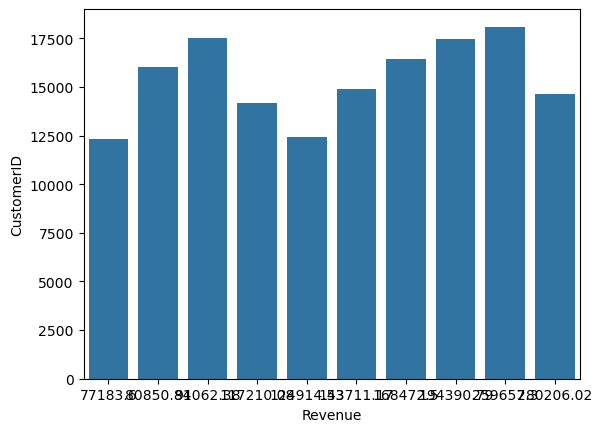

In [25]:
top_customers = (
    df.groupby('CustomerID')['Revenue'].sum().reset_index().sort_values('Revenue', ascending= False).head(10)
)

sns.barplot(
    data = top_customers,
    x = 'Revenue',
    y = 'CustomerID'
)


# 8. Revenue by Country

<Axes: xlabel='Revenue', ylabel='Country'>

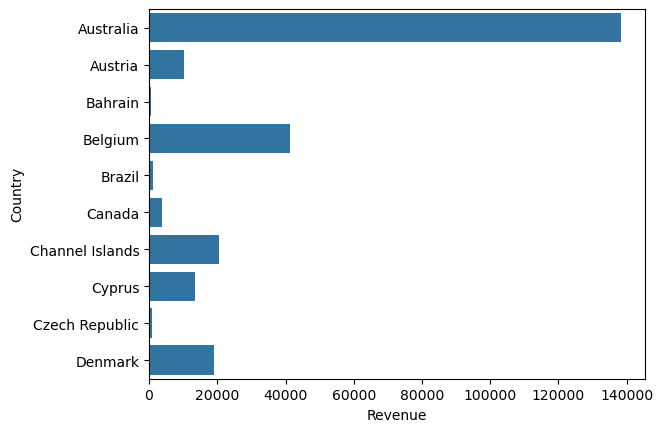

In [26]:
country_sales=(
    df.groupby('Country')['Revenue'].sum().reset_index().head(10)
)

sns.barplot(
    data = country_sales,
    x = 'Revenue',
    y = 'Country'
)

# 9. RFM Heatmap

<Axes: >

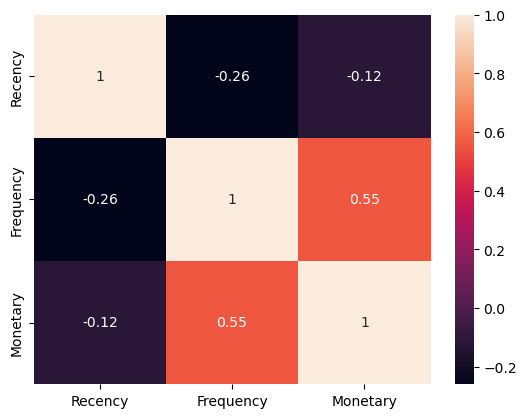

In [27]:
sns.heatmap(rfm.corr(), annot = True)

# 10. Monetary Distribution

<Axes: xlabel='Monetary', ylabel='Count'>

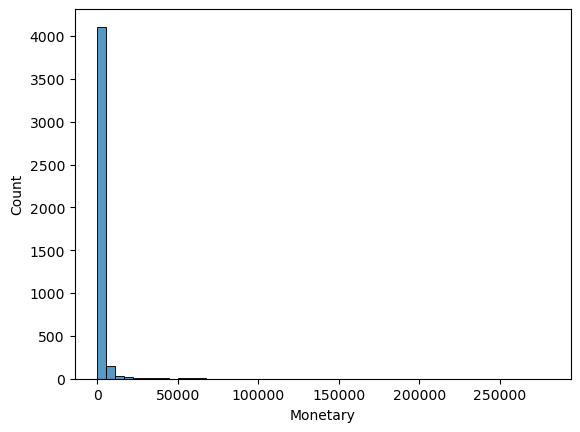

In [28]:
sns.histplot(
    rfm['Monetary'], bins= 50
)